##Частина 1. Імпорт бібліотек та завантаження даних

Завдання 1. Імпорт бібліотек

- Імпортуй усі необхідні бібліотеки для роботи з табличними даними та побудови візуалізацій.

In [1]:
# Завдання 1

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


Завдання 2. Завантаження датасету.   
- Завантаж датасет facebook_ads_data.csv.  
- Збережи дані у DataFrame `df`.  
- Відобрази перші рядки таблиці.

In [2]:
# Завдання 2

file_id = '14pJhdwhBcMr-aeewlLu4CJjX-B6wxajW'
url = f'https://drive.google.com/uc?export=download&id={file_id}'

df = pd.read_csv(url)
df.head()


,ad_date,campaign_name,total_spend,total_impressions,total_clicks,total_value,cpc,cpm,ctr,romi
0,2022-11-05,Expansion,0.00,0,0,0.00,NaN,NaN,NaN,NaN
1,2022-11-01,Expansion,0.00,0,0,0.00,NaN,NaN,NaN,NaN
2,2022-10-31,Expansion,227.45,6054,58,191.87,3.92,37.57,0.009580,0.843570
3,2022-10-30,Expansion,335.91,27562,69,472.61,4.87,12.19,0.002503,1.406954
4,2022-10-29,Expansion,714.03,33358,115,680.34,6.21,21.41,0.003447,0.952817


##Частина 2. Підготовка щоденної статистики

Завдання 3. Групування даних за датою

Створи таблицю щоденної статистики.

Необхідні результати :    
- Використано групування за `ad_date`.    
- Розраховано сумарні значення:    
`total_spend `   
`total_impressions`    
`total_clicks `   
`total_value `   
- Розраховано показник romi, як відношення `total_value` до `total_spend`.    
- Результат збережено в окремому DataFrame `daily_stats`.

In [3]:
# Завдання 3

# df.info()
# df.describe(include='all')
daily_stats = df.groupby('ad_date' ,as_index=False).agg({
    'total_spend' : 'sum',
    'total_impressions' : 'sum',
    'total_clicks' : 'sum',
    'total_value' : 'sum'
})
daily_stats['romi'] = daily_stats['total_value'] / daily_stats['total_spend']
daily_stats['romi'] = daily_stats['romi'].fillna(0)

# display(daily_stats.head())
display(daily_stats)


,ad_date,total_spend,total_impressions,total_clicks,total_value,romi
0,2020-11-11,1.89,1800,45,2.38,1.259259
1,2020-11-12,23.00,10473,397,21.13,0.918696
2,2020-11-13,6.36,11669,451,9.77,1.536164
3,2020-11-14,7.27,5005,392,12.67,1.742779
4,2020-11-15,6.98,12465,657,10.96,1.570201
...,...,...,...,...,...,...
542,2022-10-29,714.03,33358,115,680.34,0.952817
543,2022-10-30,335.91,27562,69,472.61,1.406954
544,2022-10-31,227.45,6054,58,191.87,0.843570
545,2022-11-01,0.00,0,0,0.00,0.000000


##Частина 3. Аналіз щоденних витрат на рекламу

Завдання 4. Підготовка даних за 2021 рік

Необхідні результати:   
- Створено окремий DataFrame `daily_stats_2021`.
- DataFrame містить лише записи за 2021 рік.

In [4]:
# Завдання 4

daily_stats['ad_date'] = pd.to_datetime(daily_stats['ad_date'])
daily_stats_2021 = daily_stats[daily_stats['ad_date'].dt.year == 2021]

display(daily_stats_2021.head())


,ad_date,total_spend,total_impressions,total_clicks,total_value,romi
48,2021-01-01,0.39,353,0,0.59,1.512821
49,2021-01-02,7.74,10709,205,6.90,0.891473
50,2021-01-04,70.06,22440,1256,68.47,0.977305
51,2021-01-05,81.15,60232,1379,61.68,0.760074
52,2021-01-06,142.77,65265,431,145.97,1.022414


Завдання 5. Графік щоденних витрат

Побудуй лінійний графік щоденних витрат на рекламу.

Необхідні результати :   
- Для побудови графіка використано DataFrame `daily_stats_2021`.   
- Побудовано лінійний графік.   
- На осі X відображається дата.   
- На осі Y відображається total_spend.   
- Графік містить заголовок.  

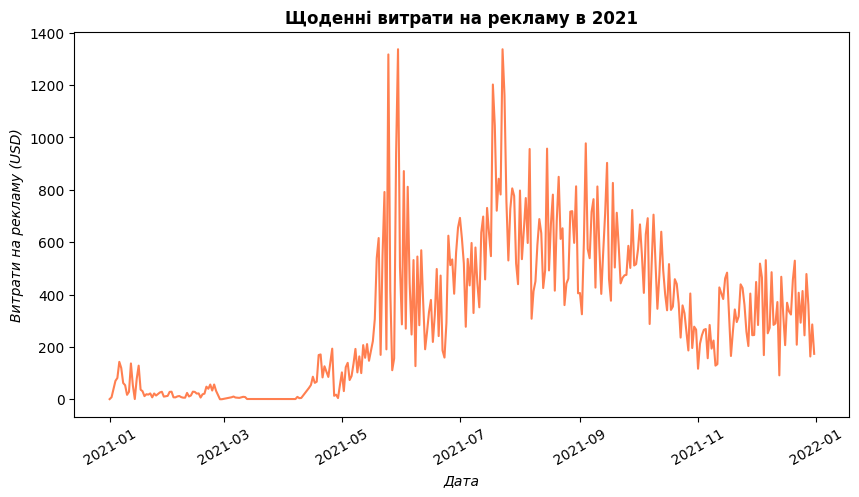

In [5]:
# Завдання 5

plt.figure(figsize=(10, 5))
# plt.plot(daily_stats_2021['ad_date'], daily_stats_2021['total_spend'])
plt.plot('ad_date', 'total_spend', data=daily_stats_2021, color='coral')
plt.xticks(rotation=30)
plt.xlabel('Дата', fontsize='medium', fontstyle='italic')
plt.ylabel('Витрати на рекламу (USD)', fontsize='medium', fontstyle='italic')
plt.title('Щоденні витрати на рекламу в 2021', fontsize='large', fontweight='bold')
plt.show()



##Частина 4. Аналіз щоденного ROMI

Завдання 6. Графік щоденного ROMI

Побудуй лінійний графік зміни ROMI за днями.

Необхідні результати :    
- Для побудови графіка використано DataFrame `daily_stats_2021`.
- Використовується показник `romi`.   
- Побудовано лінійний графік.   
- На осі X відображається дата.   
- На осі Y відображається ROMI.   
- Графік містить заголовок.   

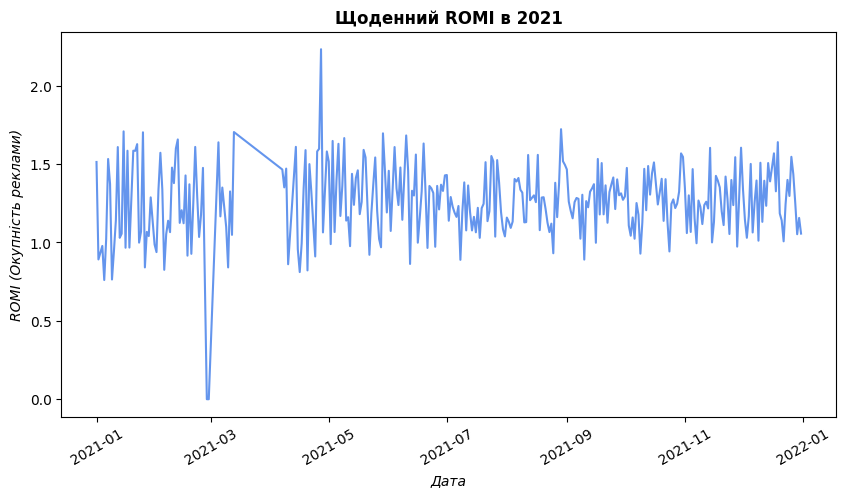

In [23]:
# Завдання 6

plt.figure(figsize=(10, 5))
plt.plot('ad_date', 'romi', data=daily_stats_2021, color='cornflowerblue')
plt.xticks(rotation=30)
plt.xlabel('Дата', fontsize='medium', fontstyle='italic')
plt.ylabel('ROMI (Окупність реклами)', fontsize='medium', fontstyle='italic')
plt.title('Щоденний ROMI в 2021', fontsize='large', fontweight='bold')
plt.show()


##Частина 5. Аналіз рекламних кампаній

Завдання 7. Групування за кампаніями

Створи агреговану таблицю за назвами кампаній.

Необхідні результати :   
- Створи DataFrame `campaign_stats`.   
- Використано групування за campaign_name.    
- Розраховано сумарні значення:    
`total_spend`   
`total_value`

In [7]:
# Завдання 7

campaign_stats = df.groupby('campaign_name' ,as_index=False).agg({
    'total_spend' : 'sum',
    'total_value' : 'sum'
})
display(campaign_stats)

,campaign_name,total_spend,total_value
0,Brand,539.92,670.15
1,Crazy discounts,2175.29,2583.59
2,Discounts,2856.39,3516.27
3,Electronics,23920.42,29169.38
4,Expansion,67212.82,83288.66
5,Hobbies,11326.97,13974.63
6,Lookalike,63631.09,80234.70
7,New items,2936.97,3742.05
8,Promos,4993.84,8793.77
9,Trendy,1992.31,3798.90


##Частина 6. Візуалізація кампаній

Завдання 8. Графік витрат за кампаніями

Побудуй стовпчиковий графік загальних витрат для кожної кампанії.

Необхідні результати :    
- Використано DataFrame `campaign_stats`.   
- Дані відсортовані за `total_spend` у спадному порядку.    
- Побудовано bar chart.   
- На графіку присутні назви кампаній.   
- Відображено показник `total_spend`.   

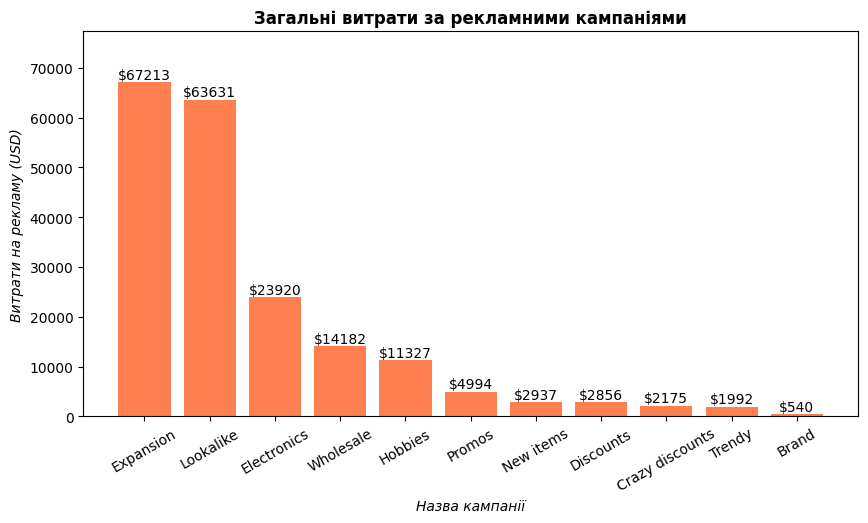

In [8]:
# Завдання 8

plt.figure(figsize=(10, 5))
campaign_stats = campaign_stats.sort_values(by='total_spend', ascending=False)
plt.bar('campaign_name', 'total_spend', data=campaign_stats, color='coral')

name = campaign_stats.set_index('campaign_name')

for n in name.index:
    plt.text(
        n,
        name.loc[n, 'total_spend'],
        '$' + str(int(round(name.loc[n, 'total_spend']))),
        ha='center',
        va='bottom'
    )

plt.title('Загальні витрати за рекламними кампаніями', fontsize='large', fontweight='bold')
plt.xticks(rotation=30)
plt.xlabel('Назва кампанії', fontsize='medium', fontstyle='italic')
plt.ylabel('Витрати на рекламу (USD)', fontsize='medium', fontstyle='italic')
plt.ylim(0, name['total_spend'].max() * 1.15)
plt.show()


Завдання 9. Графік ROMI за кампаніями

Розрахуй ROMI для кожної кампанії та побудуй стовпчиковий графік.

Необхідні результати :  
- Використано DataFrame `campaign_stats`.   
- Створено колонку `romi`.    
- ROMI розраховано як:    
`total_value / total_spend`  
- Дані відсортовані за `romi` у спадному порядку.
- Побудовано bar chart.
- На графіку присутні назви кампаній.
- Відображено показник `romi`.

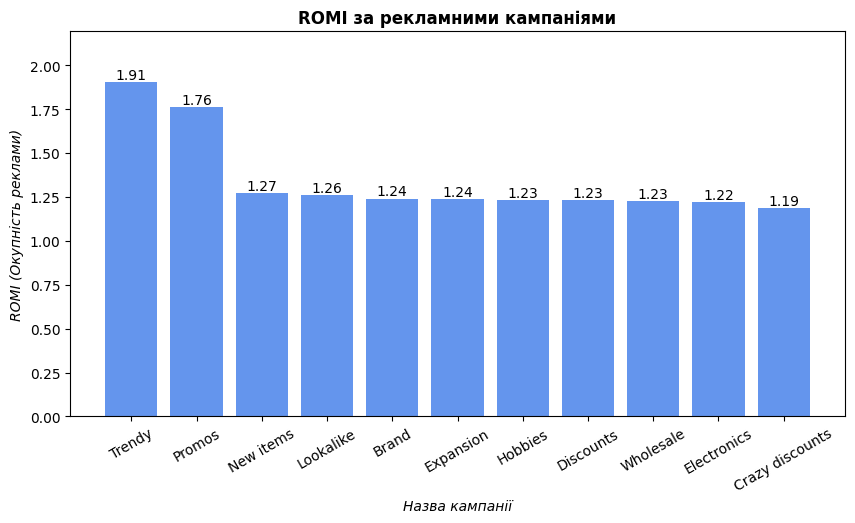

In [22]:
# Завдання 9

campaign_stats['romi'] = campaign_stats['total_value'] / campaign_stats['total_spend']
campaign_stats['romi'] = campaign_stats['romi'].fillna(0)

plt.figure(figsize=(10, 5))
campaign_stats = campaign_stats.sort_values(by='romi', ascending=False)
plt.bar('campaign_name', 'romi', data=campaign_stats, color='cornflowerblue')

name = campaign_stats.set_index('campaign_name')

for n in name.index:
    plt.text(
        n,
        name.loc[n, 'romi'],
        str(round(name.loc[n, 'romi'], 2)),
        ha='center',
        va='bottom'
    )
plt.title('ROMI за рекламними кампаніями', fontsize='large', fontweight='bold')
plt.xticks(rotation=30)
plt.xlabel('Назва кампанії', fontsize='medium', fontstyle='italic')
plt.ylabel('ROMI (Окупність реклами)', fontsize='medium', fontstyle='italic')
plt.ylim(0, name['romi'].max() * 1.15)

plt.show()


##Частина 7. Аналіз розподілів

Завдання 10. Box Plot ROMI по кампаніях

Побудуй box plot для аналізу розкиду значень ROMI у різних кампаніях.

Необхідні результати :
- Використано DataFrame `df`.
- Використано `campaign_name`.
- Використано `romi`.
- Побудовано box plot.  

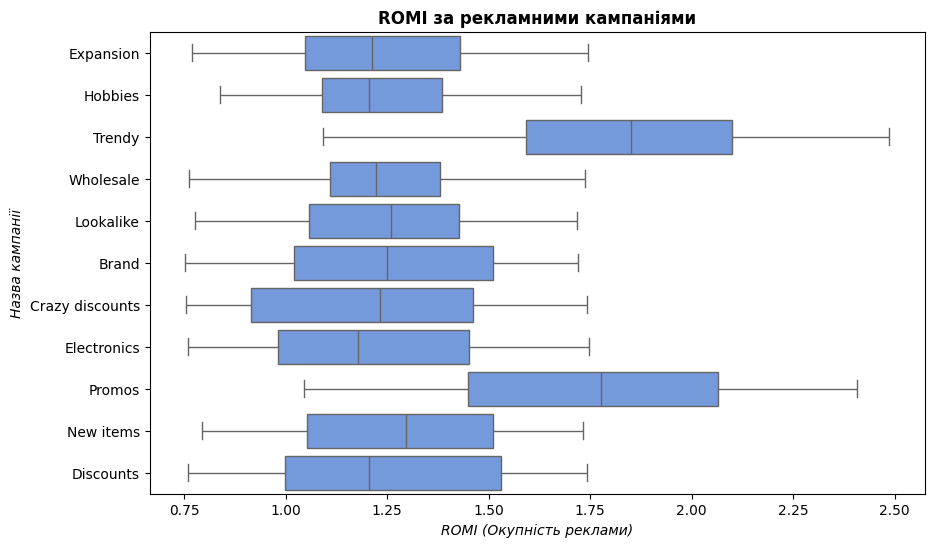

In [21]:
# Завдання 10

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='romi', y='campaign_name', color='cornflowerblue')

plt.title('ROMI за рекламними кампаніями', fontsize='large', fontweight='bold')
plt.xlabel('ROMI (Окупність реклами)', fontsize='medium', fontstyle='italic')
plt.ylabel('Назва кампанії', fontsize='medium', fontstyle='italic')

plt.show()


Завдання 11. Гістограма ROMI

Побудуй гістограму розподілу значень ROMI.

Необхідні результати :
- Використано DataFrame `df`.
- Побудовано гістограму.
- Використовується колонка `romi`.   

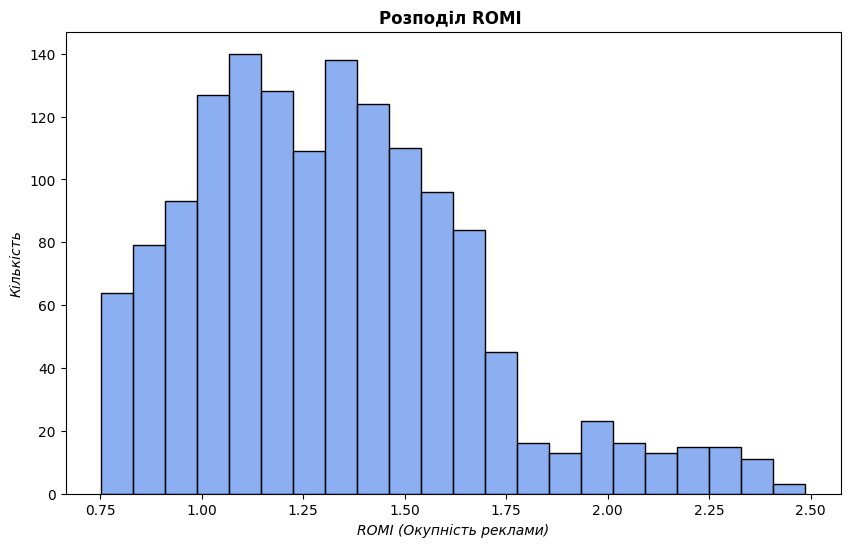

In [20]:
# Завдання 11

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='romi', color='cornflowerblue')

plt.title('Розподіл ROMI ', fontsize='large', fontweight='bold')
plt.xlabel('ROMI (Окупність реклами)', fontsize='medium', fontstyle='italic')
plt.ylabel('Кількість', fontsize='medium', fontstyle='italic')

plt.show()


##Частина 8. Кореляція та регресія

Завдання 12. Теплова карта кореляцій

Побудуй теплову карту кореляції між усіма числовими змінними.

Необхідні результати :     
- Використано DataFrame `df`.
- Розраховано кореляційну матрицю для числових колонок.
- Побудовано heatmap на основі кореляційної матриці.

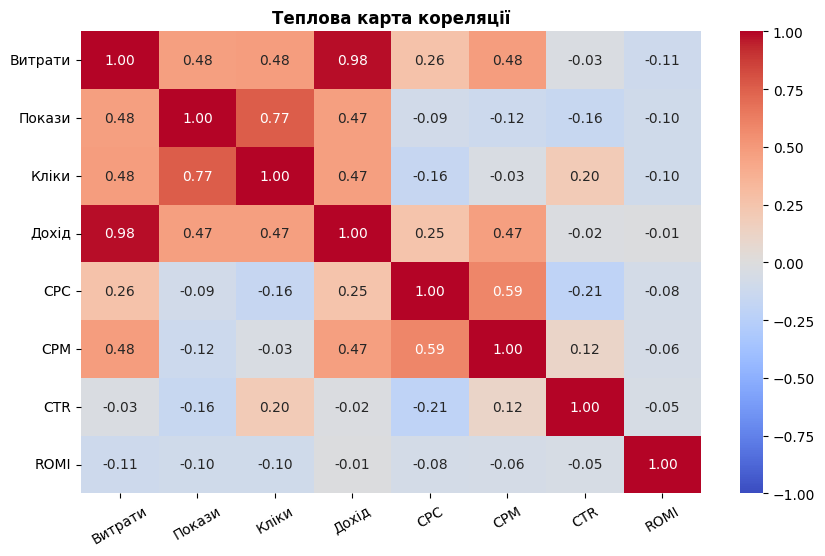

In [17]:
# Завдання 12

corr = df.select_dtypes(include=['number']).corr()

labels = {
    'total_spend': 'Витрати',
    'total_impressions': 'Покази',
    'total_clicks': 'Кліки',
    'total_value': 'Дохід',
    'cpc': 'CPC',
    'cpm': 'CPM',
    'ctr': 'CTR',
    'romi': 'ROMI'
}
corr = corr.rename(index=labels, columns=labels)

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Теплова карта кореляції', fontsize='large', fontweight='bold')
plt.xticks(rotation=30)
plt.yticks(rotation=0)
plt.show()


Завдання 13. Точкова діаграма з лінійною регресією

Побудуй scatter plot з лінією регресії для змінних:  
`total_spend`
`total_value`

Необхідні результати :   
- Використано DataFrame `df`.
- Використано `lmplot()`.
- Використано змінні `total_spend` та `total_value`.
- На графіку присутня регресійна лінія.

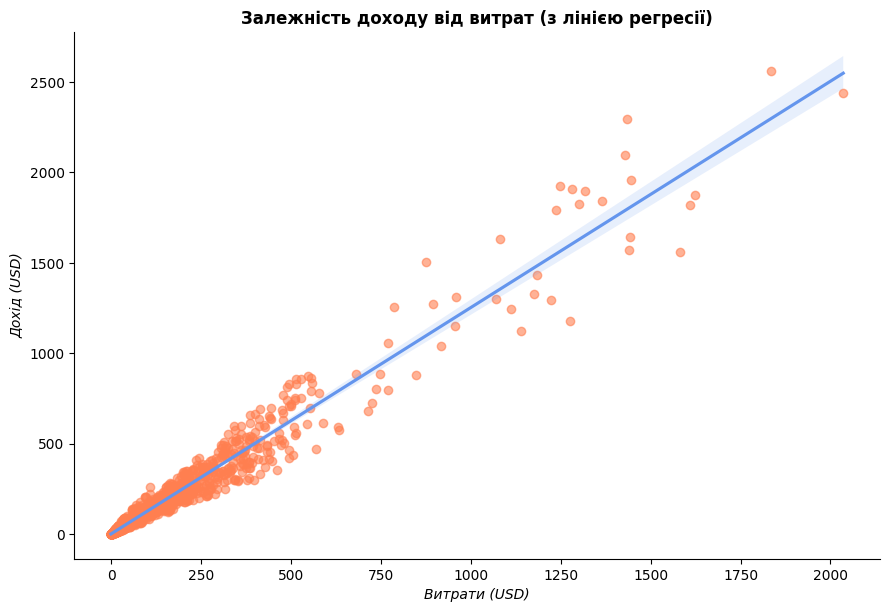

In [25]:
# Завдання 13

sns.lmplot(data=df, x='total_spend', y='total_value', height=6, aspect=1.5,
    scatter_kws={'color': 'coral', 'alpha': 0.6},
    line_kws={'color': 'cornflowerblue'})

plt.title('Залежність доходу від витрат (з лінією регресії)', fontsize='large', fontweight='bold')
plt.xlabel('Витрати (USD)', fontsize='medium', fontstyle='italic')
plt.ylabel('Дохід (USD)', fontsize='medium', fontstyle='italic')

plt.show()
